# Basic ECA&D OGC EDR API demo for the RODEO project

This notebook gives a compact introduction to the ECA&D non-blended collection exposed through the OGC Environmental Data Retrieval (EDR) API. It focuses on the first things a user usually wants to do: find stations, inspect one station in detail, request observations for a small area, and download station data as NetCDF.

Each API request prints the full URL before the response is processed. This makes the notebook useful even if you are not focused on Python: the printed URL shows what the API call looks like and can be copied into a browser or another client.

The notebook is structured as follows:
1. Configure the API endpoint and define small request helpers.
2. Retrieve station information from the `/locations` endpoint.
3. Request one station using the `/locations/{id}` endpoint.
4. Request a time series around De Bilt using the `/cube` endpoint.
5. Download station data in NetCDF format using `f=netCDF4`.

Last update: 2026.05.28

J.R. Angevaare (joran.angevaare@knmi.nl)

## Setup

This block imports the packages used in the notebook. We use `requests` for API calls, `pandas` for tabular data, and `matplotlib` for a simple time-series plot.

In [1]:
from pathlib import Path
import time
import pprint

import pandas as pd
import requests
import matplotlib.pyplot as plt
import xarray as xr

This block defines the base API URL, the collection name, and the example station id used throughout the notebook. The example station id is used for the `/locations/{id}` and NetCDF download examples.

In [2]:
base_url = "https://api.meteogate.eu/eu-eumetnet-climate-observations/v1"
collection = "ecad-nonblended"
station_id = "ecad_0000162"
SCREEN_WIDTH = 120

This helper makes the API examples easier to follow. It prints the full request URL before making the request, reports how long the request took, checks whether the HTTP response was successful, and returns the JSON response as a Python dictionary. The printed URL is the key part for non-Python users: it exposes the endpoint and query parameters used by the API.

In [3]:
def get_json(url, params=None, **kwargs):
    request = requests.Request("GET", url, params=params, **kwargs).prepare()
    print(request.url)

    t0 = time.time()
    response = requests.get(url, params=params, **kwargs)
    print(f"API call took {time.time() - t0:.2g} s")

    response.raise_for_status()
    return response.json()

## Retrieve station information

The `/locations` endpoint returns the stations in the collection. Each station is represented as a feature with an id, coordinates, and metadata such as station name, country code, elevation, and the variables provided by data providers. When the next cell runs, the first output line is the exact URL for this station-list request.

In [4]:
stations = get_json(f"{base_url}/collections/{collection}/locations")

print(f"Number of stations returned: {len(stations['features'])}")
print("\nExample station feature:")
pprint.pprint(stations["features"][0], width=SCREEN_WIDTH)

https://api.meteogate.eu/eu-eumetnet-climate-observations/v1/collections/ecad-nonblended/locations
API call took 8.1 s
Number of stations returned: 22215

Example station feature:
{'geometry': {'coordinates': [14.8, 56.86667], 'type': 'Point'},
 'id': 'ecad_0000001',
 'properties': {'country_code': 'SE',
                'height_above_mean_sea_level': 166.0,
                'provider': {'Marcus Flarup': {'cc13': [['1961-01-02T00:00:00', '1995-11-15T00:00:00']],
                                               'dd4': [['1947-01-02T00:00:00', '1995-11-15T00:00:00']],
                                               'pp18': [['1961-01-02T00:00:00', '1995-11-15T00:00:00']],
                                               'rr9': [['1860-01-02T00:00:00', '2019-09-17T00:00:00']],
                                               'sd5': [['1881-10-27T00:00:00', '2019-05-01T00:00:00']],
                                               'tg6': [['1860-01-02T00:00:00', '2006-12-01T00:00:00']],
              

This block flattens a few useful station fields into a `pandas` table. A table is often easier to search, filter, or export than the nested CovJson (GeoJSON-like) response.

In [5]:
stations_dataframe = pd.DataFrame(
    {
        "station_id": [feature["id"] for feature in stations["features"]],
        "station_name": [
            feature["properties"]["station_name"] for feature in stations["features"]
        ],
        "country_code": [
            feature["properties"].get("country_code")
            for feature in stations["features"]
        ],
        "height_above_mean_sea_level": [
            feature["properties"].get("height_above_mean_sea_level")
            for feature in stations["features"]
        ],
        "lon": [
            feature["geometry"]["coordinates"][0] for feature in stations["features"]
        ],
        "lat": [
            feature["geometry"]["coordinates"][1] for feature in stations["features"]
        ],
    }
)

stations_dataframe.head()

,station_id,station_name,country_code,height_above_mean_sea_level,lon,lat
0,ecad_0000001,Vaexjoe,SE,166.0,14.80000,56.86667
1,ecad_0000002,Falun,SE,160.0,15.61667,60.61667
2,ecad_0000003,Stensele,SE,325.0,17.16639,65.06667
3,ecad_0000004,Linkoeping,SE,93.0,15.53306,58.40000
4,ecad_0000005,Linkoeping-Malmslaett,SE,93.0,15.53306,58.40000


## Request one station with `/locations/{id}`

Once we know a station id, we can request that station directly. This is useful when an application or another query already knows the station id and only needs metadata or observations for that location. The printed URL shows how the station id, time range, and requested variables are encoded in the API call.

In [6]:
single_station = get_json(
    f"{base_url}/collections/{collection}/locations/{station_id}",
    params={
        "datetime": "2026-01-01T00:00:00Z/2026-01-10T00:00:00Z",
        "standard_name": "precipitation_amount,wind_speed",
    },
)

pprint.pprint(single_station, width=SCREEN_WIDTH)

https://api.meteogate.eu/eu-eumetnet-climate-observations/v1/collections/ecad-nonblended/locations/ecad_0000162?datetime=2026-01-01T00%3A00%3A00Z%2F2026-01-10T00%3A00%3A00Z&standard_name=precipitation_amount%2Cwind_speed
API call took 6.1 s
{'coverages': [{'domain': {'axes': {'t': {'values': ['2026-01-01T00:00:00Z',
                                                     '2026-01-02T00:00:00Z',
                                                     '2026-01-03T00:00:00Z',
                                                     '2026-01-04T00:00:00Z',
                                                     '2026-01-05T00:00:00Z',
                                                     '2026-01-06T00:00:00Z',
                                                     '2026-01-07T00:00:00Z',
                                                     '2026-01-08T00:00:00Z',
                                                     '2026-01-09T00:00:00Z',
                                                     '2026-01-10T0

## Request observations with `/cube`

The `/cube` endpoint can be used to retrieve observations for a bounding box and time range. This example requests mean air temperature for a larger box, so the response can include multiple station coverages. Each coverage also contains station coordinates in the domain axes, which we keep in the DataFrame. The printed URL shows the bbox, time range, variable, and method used in the API request.

In [7]:
cube_params = {
    "method": "mean",
    "standard_name": "air_temperature",
    "bbox": "5,40,10,50",
    "datetime": "2020-12-31T00:00:00Z/2021-01-01T00:00:00Z",
}

data_cube = get_json(f"{base_url}/collections/{collection}/cube", cube_params)

dataframe_cube = pd.concat(
    [
        pd.DataFrame(
            {
                "station_id": coverage.get("eumetnet:locationId"),
                "lon": coverage["domain"]["axes"]["x"]["values"][0],
                "lat": coverage["domain"]["axes"]["y"]["values"][0],
                "end_time": pd.to_datetime(coverage["domain"]["axes"]["t"]["values"]),
                **{
                    parameter_name: coverage["ranges"][parameter_name]["values"]
                    for parameter_name in coverage["ranges"]
                },
            }
        )
        for coverage in data_cube["coverages"]
    ],
    ignore_index=True,
)

dataframe_cube.head()

https://api.meteogate.eu/eu-eumetnet-climate-observations/v1/collections/ecad-nonblended/cube?method=mean&standard_name=air_temperature&bbox=5%2C40%2C10%2C50&datetime=2020-12-31T00%3A00%3A00Z%2F2021-01-01T00%3A00%3A00Z
API call took 0.62 s


,station_id,lon,lat,end_time,tg21,tg21_q,tg5,tg5_q,tg3,tg3_q,tg24,tg24_q
0,ecad_0000037,5.07778,45.72639,2020-12-31 00:00:00+00:00,2.6,0.0,2.2,0.0,NaN,NaN,NaN,NaN
1,ecad_0000037,5.07778,45.72639,2021-01-01 00:00:00+00:00,3.8,0.0,3.2,0.0,NaN,NaN,NaN,NaN
2,ecad_0000039,5.21583,43.43778,2020-12-31 00:00:00+00:00,4.1,0.0,4.0,0.0,NaN,NaN,NaN,NaN
3,ecad_0000039,5.21583,43.43778,2021-01-01 00:00:00+00:00,4.8,0.0,3.7,0.0,NaN,NaN,NaN,NaN
4,ecad_0000050,7.73667,49.42528,2020-12-31 00:00:00+00:00,NaN,NaN,NaN,NaN,3.0,0.0,NaN,NaN


Now that the cube response is in a DataFrame, we can do a small station comparison. Temperature can be returned in several parameter columns, depending on the station and provider. This block combines the available `tg21`, `tg5`, `tg3`, and `tg24` columns into one analysis column, records which source column was used, joins station metadata, and calculates summary values per station.

In [8]:
temperature_columns = [
    column
    for column in ["tg21", "tg5", "tg3", "tg24"]
    if column in dataframe_cube.columns
]

dataframe_cube["air_temperature"] = (
    dataframe_cube[temperature_columns].bfill(axis=1).iloc[:, 0]
)
has_temperature = dataframe_cube[temperature_columns].notna().any(axis=1)
dataframe_cube["air_temperature_source"] = (
    dataframe_cube[temperature_columns].notna().idxmax(axis=1).where(has_temperature)
)

description = "Air temperature"
unit = data_cube["parameters"][temperature_columns[0]]["unit"]["symbol"]["value"]

station_summary = (
    dataframe_cube.groupby(["station_id", "lon", "lat"], as_index=False)
    .agg(
        mean_value=("air_temperature", "mean"),
        min_value=("air_temperature", "min"),
        max_value=("air_temperature", "max"),
        source_columns=(
            "air_temperature_source",
            lambda values: ", ".join(sorted(set(values.dropna()))),
        ),
    )
    .merge(
        stations_dataframe[["station_id", "station_name", "country_code"]],
        on="station_id",
        how="left",
    )
    .sort_values("mean_value", ascending=False)
)
station_summary = station_summary.dropna()
station_summary[
    [
        "station_id",
        "station_name",
        "country_code",
        "lon",
        "lat",
        "source_columns",
        "mean_value",
        "min_value",
        "max_value",
    ]
]

,station_id,station_name,country_code,lon,lat,source_columns,mean_value,min_value,max_value
129,ecad_0011272,Cap Corse,FR,9.35917,43.00333,tg21,9.90,9.4,10.4
530,ecad_0025633,Bauladu,IT,8.67056,40.02389,tg24,9.80,7.9,11.7
531,ecad_0025634,Baunei,IT,9.65000,40.04417,tg24,9.80,9.8,9.8
131,ecad_0011274,Alistro,FR,9.54139,42.25917,tg21,9.65,9.4,9.9
126,ecad_0011268,Cap Pertusato,FR,9.17806,41.37444,tg21,9.50,8.6,10.4
...,...,...,...,...,...,...,...,...,...
415,ecad_0021561,Tignes Sapc,FR,6.90694,45.46667,tg21,-10.20,-12.3,-8.1
7,ecad_0000243,Saentis,CH,9.35000,47.25000,tg3,-10.85,-11.4,-10.3
205,ecad_0020864,Ristolas,FR,6.98417,44.76556,tg21,-11.65,-13.6,-9.7
23,ecad_0001649,Col Du Grand St-Bernard,CH,7.16667,45.86667,tg3,-11.70,-12.1,-11.3


This block plots the station summary on a simple longitude-latitude scatter plot. The color shows the mean value for the requested period, which makes it easy to compare the stations returned by the bounding-box query.

(40.0, 50.0)

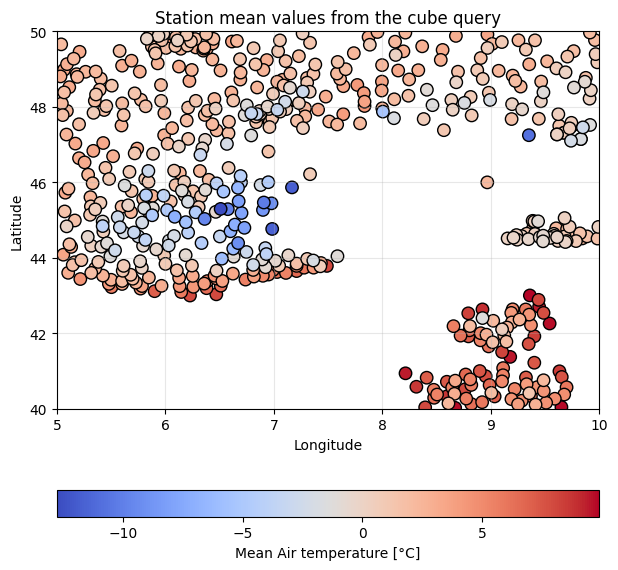

In [9]:
plt.figure(figsize=(7, 7))

scatter = plt.scatter(
    station_summary["lon"],
    station_summary["lat"],
    c=station_summary["mean_value"],
    s=80,
    cmap="coolwarm",
    edgecolor="black",
)


plt.colorbar(scatter, label=f"Mean {description} [{unit}]", orientation="horizontal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Station mean values from the cube query")
plt.grid(True, alpha=0.3)
bbox_float = [float(c) for c in cube_params["bbox"].split(",")]
plt.xlim(bbox_float[::2])
plt.ylim(bbox_float[1::2])

## Download station data as NetCDF

The API can also return data in NetCDF format by adding `f=netCDF4` to the request. This is useful when the data should be stored, shared, or opened in tools that work directly with NetCDF files. The next cell prints the NetCDF request URL before downloading the file.

In [10]:
netcdf_params = {
    "datetime": "2026-01-01T00:00:00Z/..",
    "f": "netCDF4",
}

netcdf_url = f"{base_url}/collections/{collection}/locations/{station_id}"
prepared_url = requests.Request("GET", netcdf_url, params=netcdf_params).prepare().url
print(prepared_url)

response = requests.get(netcdf_url, params=netcdf_params)
response.raise_for_status()

output_dir = Path("downloads")
output_dir.mkdir(exist_ok=True)
output_path = output_dir / f"{station_id}_from_2026-01-01.nc"
output_path.write_bytes(response.content)

print(f"Downloaded {len(response.content):,} bytes")
print(f"Content-Type: {response.headers.get('content-type')}")
print(f"Saved to: {output_path}")

https://api.meteogate.eu/eu-eumetnet-climate-observations/v1/collections/ecad-nonblended/locations/ecad_0000162?datetime=2026-01-01T00%3A00%3A00Z%2F..&f=netCDF4
Downloaded 60,260 bytes
Content-Type: application/x-netcdf
Saved to: downloads/ecad_0000162_from_2026-01-01.nc


The previous block downloads the NetCDF file to disk, which is enough if you want to store the data or open it in another application. Let's now open it, and use it to easily replicate the case above:

/Users/angevaare/miniforge3/envs/py313/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/angevaare/miniforge3/envs/py313/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


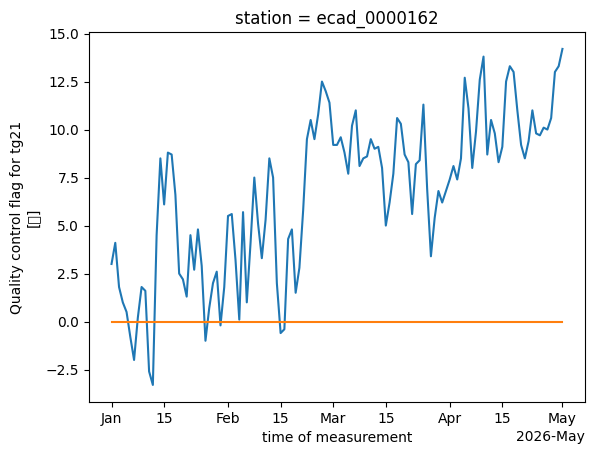

In [11]:
ds = xr.open_dataset(output_path)
ds["tg21"].plot()
ds["tg21_q"].plot()